In [1]:
%env

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn.functional as F
from PIL import Image
from rasterio.enums import Resampling
from torchvision import transforms
from tqdm import tqdm

# Filter warnings.
warnings.filterwarnings("ignore", message=".*invalid escape sequence.*")

# Torch performance.
torch.set_float32_matmul_precision("high")

VISLOC_ROOT = Path(os.environ["VISLOC_ROOT"])
DIFFUSIONSAT_256_CHCKPT = Path(os.environ["DIFFUSIONSAT_256_CHCKPT"])

RANDOM_SEED = 42
DEVICE = torch.device("cuda")
NUM_WORKERS = 4

## Data


In [2]:
import torch
from torch.utils.data import Dataset

FLIGHT_ID = "03"


def _read_sat_bounds(root: Path, flight_id: str) -> tuple[float, float, float, float]:
  """Returns (lat_min, lon_min, lat_max, lon_max) from satellite_coordinates_range.csv."""
  df = pd.read_csv(root / "satellite_coordinates_range.csv")
  row = df[df["mapname"] == f"satellite{flight_id}.tif"].iloc[0]
  return (
    float(row["RB_lat_map"]),
    float(row["LT_lon_map"]),
    float(row["LT_lat_map"]),
    float(row["RB_lon_map"]),
  )


class UAVDataset(Dataset):
  """VisLoc UAV drone images. Used as the query set for evaluation only — never for training."""

  def __init__(self, root: Path, flight_id: str, transform=None):
    self.drone_dir = root / flight_id / "drone"
    self.transform = transform
    df = pd.read_csv(root / flight_id / f"{flight_id}.csv")
    self.records = df[["filename", "lat", "lon"]].reset_index(drop=True)

  def __len__(self) -> int:
    return len(self.records)

  def __getitem__(self, idx: int):
    row = self.records.iloc[idx]
    img = Image.open(self.drone_dir / row["filename"]).convert("RGB")
    if self.transform is not None:
      img = self.transform(img)
    return img, float(row["lat"]), float(row["lon"])


class SatChunkDataset(Dataset):
  """Fixed, evenly-tiled satellite chunks for the retrieval reference database.

  The full tiff is loaded into RAM at init; chunks are pure numpy slices.

  At 0.3 m/px satellite GSD, chunk_pixels=256 covers ~76.8m per side —
  large enough to contain any UAV image footprint (25–50m) with margin.
  stride_pixels=128 (50% overlap) ensures every GPS point falls in ≥4 chunks.

  Exposes `gt_chunks` for use with build_ground_truth().

  Args:
    root:          VisLoc dataset root.
    flight_id:     Flight identifier (e.g. "03").
    chunk_pixels:  Crop size in original tiff pixels (controls ground coverage).
    stride_pixels: Stride in original tiff pixels between chunk origins.
    output_size:   Spatial dims of the returned image after resize.
    transform:     Applied to each PIL image before returning.
  """

  def __init__(
    self,
    root: Path,
    flight_id: str,
    chunk_pixels: int = 256,
    stride_pixels: int = 128,
    output_size: int = 256,
    transform=None,
  ):
    self.chunk_pixels = chunk_pixels
    self.output_size = output_size
    self.transform = transform

    lat_min, lon_min, lat_max, lon_max = _read_sat_bounds(root, flight_id)

    sat_path = root / flight_id / f"satellite{flight_id}.tif"
    with rasterio.open(sat_path) as src:
      data = src.read([1, 2, 3])  # (3, H, W)
    self._img = np.transpose(data, (1, 2, 0))  # (H, W, 3) uint8
    orig_h, orig_w = self._img.shape[:2]

    self._chunks: list[tuple[int, int, float, float]] = []
    self._bboxes: list[tuple[float, float, float, float]] = []

    for y in range(0, orig_h - chunk_pixels, stride_pixels):
      for x in range(0, orig_w - chunk_pixels, stride_pixels):
        cx = x + chunk_pixels // 2
        cy = y + chunk_pixels // 2
        lat = lat_max - (cy / orig_h) * (lat_max - lat_min)
        lon = lon_min + (cx / orig_w) * (lon_max - lon_min)
        self._chunks.append((x, y, lat, lon))

        blat_max = lat_max - (y / orig_h) * (lat_max - lat_min)
        blat_min = lat_max - ((y + chunk_pixels) / orig_h) * (lat_max - lat_min)
        blon_min = lon_min + (x / orig_w) * (lon_max - lon_min)
        blon_max = lon_min + ((x + chunk_pixels) / orig_w) * (lon_max - lon_min)
        self._bboxes.append((blat_min, blon_min, blat_max, blon_max))

  @property
  def gt_chunks(self) -> list[dict]:
    """List of {bbox_gps} dicts compatible with build_ground_truth()."""
    return [{"bbox_gps": bb} for bb in self._bboxes]

  def __len__(self) -> int:
    return len(self._chunks)

  def __getitem__(self, idx: int):
    x, y, lat, lon = self._chunks[idx]
    crop = self._img[y : y + self.chunk_pixels, x : x + self.chunk_pixels]
    img = Image.fromarray(crop).resize(
      (self.output_size, self.output_size), Image.LANCZOS
    )
    if self.transform is not None:
      img = self.transform(img)
    return img, lat, lon


class SatSimDataset(Dataset):
  """Random crops from the satellite tiff for self-supervised training.

  The full tiff is loaded into RAM at init so that all crop reads are pure
  numpy slices — no file I/O or decompression on the training hot path.

  Returns two views of the same geographic region as a positive pair:
  - sat_view:  larger crop, lightly augmented — stands in for the satellite reference.
  - uav_view:  smaller crop of the same centre, heavily augmented — simulates a UAV image.

  At 0.3 m/px satellite GSD:
  - uav_crop_range=(80, 170) → 24–51m ground coverage, matching real UAV FOV.
  - sat_crop_range=(256, 512) → 77–154m, providing wider context for the reference.

  Args:
    root:            VisLoc dataset root.
    flight_id:       Flight identifier (e.g. "03").
    output_size:     Both views are returned at this square resolution.
    sat_crop_range:  (min, max) crop size in original tiff pixels for the satellite view.
    uav_crop_range:  (min, max) crop size for the UAV-simulated view.
    sat_transform:   Transform applied to the satellite PIL crop.
    uav_transform:   Transform applied to the UAV-simulated PIL crop.
    n_samples:       Virtual dataset length / epoch size.
  """

  def __init__(
    self,
    root: Path,
    flight_id: str,
    output_size: int = 256,
    sat_crop_range: tuple[int, int] = (256, 512),
    uav_crop_range: tuple[int, int] = (80, 170),
    sat_transform=None,
    uav_transform=None,
    n_samples: int = 10_000,
  ):
    self.output_size = output_size
    self.sat_crop_range = sat_crop_range
    self.uav_crop_range = uav_crop_range
    self.sat_transform = sat_transform
    self.uav_transform = uav_transform
    self.n_samples = n_samples

    self._lat_min, self._lon_min, self._lat_max, self._lon_max = _read_sat_bounds(
      root, flight_id
    )

    sat_path = root / flight_id / f"satellite{flight_id}.tif"
    with rasterio.open(sat_path) as src:
      data = src.read([1, 2, 3])  # (3, H, W)
    self._img = np.transpose(data, (1, 2, 0))  # (H, W, 3) uint8
    self.orig_h, self.orig_w = self._img.shape[:2]

  def __len__(self) -> int:
    return self.n_samples

  def _read_crop(self, cx: int, cy: int, crop_size: int) -> Image.Image:
    x0 = max(0, cx - crop_size // 2)
    y0 = max(0, cy - crop_size // 2)
    crop = self._img[y0 : y0 + crop_size, x0 : x0 + crop_size]
    return Image.fromarray(crop).resize(
      (self.output_size, self.output_size), Image.LANCZOS
    )

  def __getitem__(self, idx: int):
    sat_crop = random.randint(*self.sat_crop_range)
    uav_crop = random.randint(*self.uav_crop_range)
    margin = sat_crop // 2

    cx = random.randint(margin, self.orig_w - margin)
    cy = random.randint(margin, self.orig_h - margin)

    lat = self._lat_max - (cy / self.orig_h) * (self._lat_max - self._lat_min)
    lon = self._lon_min + (cx / self.orig_w) * (self._lon_max - self._lon_min)

    sat_img = self._read_crop(cx, cy, sat_crop)
    uav_img = self._read_crop(cx, cy, uav_crop)

    if self.sat_transform is not None:
      sat_img = self.sat_transform(sat_img)
    if self.uav_transform is not None:
      uav_img = self.uav_transform(uav_img)

    return sat_img, uav_img, lat, lon

## Definitions


In [3]:
# Defaults for LDM feature extraction.


from dataclasses import dataclass, field


@dataclass
class LDMExtractorCfg:
  img_size: int = 256
  batch_size: int = 8
  save_timesteps: list = field(default_factory=lambda: [48, 46, 42])
  num_timesteps: int = 50
  layer_idxs: dict = field(default_factory=lambda: {"down_blocks": {"attn1": "all"}})
  diffusion_mode: str = "inversion"
  prompt: str = "A satellite image"
  negative_prompt: str = ""
  resize_outputs: int = -1
  max_i: int | None = None
  min_i: int | None = None

  def get(self, key, default=None):
    return getattr(self, key, default)


In [4]:
# Evaluation.
#
# For u2s retrieval, each UAV image may match multiple satellite chunks (overlapping tiles).
# ground_truth is a list of sets of valid chunk indices.


def build_ground_truth(
  uav_lats: np.ndarray,
  uav_lons: np.ndarray,
  chunks: list[dict],
) -> list[set]:
  """For each UAV image, find all satellite chunk indices whose GPS bbox contains it.
  Falls back to the nearest chunk if no bbox contains the point."""
  ground_truth = []
  for lat, lon in zip(uav_lats, uav_lons):
    matching = set()
    for i, chunk in enumerate(chunks):
      lat_min, lon_min, lat_max, lon_max = chunk["bbox_gps"]
      if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
        matching.add(i)
    if not matching:
      dists = [(lat - c["lat"]) ** 2 + (lon - c["lon"]) ** 2 for c in chunks]
      matching = {int(np.argmin(dists))}
    ground_truth.append(matching)
  return ground_truth


def recall_at_k(preds: np.ndarray, ground_truth: list[set], k: int) -> float:
  """Recall@k with multi-match ground truth."""
  hits = sum(any(p in gt for p in preds[i, :k]) for i, gt in enumerate(ground_truth))
  return hits / len(ground_truth)


def calculate_metrics(preds: np.ndarray, ground_truth: list[set]) -> dict:
  return {
    "Recall@1": recall_at_k(preds, ground_truth, k=1),
    "Recall@5": recall_at_k(preds, ground_truth, k=5),
    "Recall@10": recall_at_k(preds, ground_truth, k=10),
  }

In [5]:
import math
from typing import Literal

import lightning as L
import torch
from archs.embedders import FuserEmbedder
from archs.ldm_extractor import LDMExtractor
from archs.losses import SpatialLoss
from archs.retrievers import FAISSRetriever
from diffusers import AutoencoderKL
from diffusionsat import DiffusionSatPipeline
from torch.utils.data import DataLoader


class FuserEmbedderModule(L.LightningModule):
  def __init__(
    self,
    vae: AutoencoderKL,
    pipe: DiffusionSatPipeline,
    val_chunk_dataset: "SatChunkDataset | None" = None,
    # General
    img_size: Literal[256] = 256,
    batch_size: int = 16,
    val_batch_size: int = 32,
    # LDM extractor
    save_timesteps: list = [48, 46, 42],
    num_timesteps: int = 50,
    layer_idxs: dict = {"down_blocks": {"attn1": "all"}},
    diffusion_mode: str = "inversion",
    prompt: str = "A satellite image",
    negative_prompt: str = "",
    resize_outputs: int = -1,
    # Loss
    vicreg_alpha: float = 0.5,
    # Training
    lr: float = 1e-2,
    weight_decay: float = 1e-4,
    min_lr: float = 1e-5,
    warmup_epochs: int = 5,
    max_train_epochs: int = 40,
  ):
    super().__init__()
    self.save_hyperparameters(ignore=["vae", "pipe", "val_chunk_dataset"])

    # Frozen backbones.
    self.vae = vae
    ldm_cfg = LDMExtractorCfg(img_size=img_size, batch_size=batch_size, save_timesteps=save_timesteps, num_timesteps=num_timesteps, layer_idxs=layer_idxs, diffusion_mode=diffusion_mode, prompt=prompt, negative_prompt=negative_prompt, resize_outputs=resize_outputs)  # fmt: off
    self.ldm_extractor = LDMExtractor(ldm_cfg, pipe)

    # Validation dataset.
    self._val_chunk_dataset = val_chunk_dataset

    # Trainable head.
    self.embedder = FuserEmbedder(
      save_timesteps=self.ldm_extractor.save_timesteps,
      feature_dims=self.ldm_extractor.collected_dims,
    )

    self.criterion = SpatialLoss(alpha=vicreg_alpha)

  # ------------------------------------------------------------------
  # Helpers
  # ------------------------------------------------------------------

  @torch.no_grad()
  def _backbone_forward(self, imgs: torch.Tensor) -> dict:
    latents = self.vae.encode(imgs).latent_dist.sample() * 0.18215
    feats, _ = self.ldm_extractor.forward(latents)
    return feats

  @torch.no_grad()
  def _embed(self, imgs: torch.Tensor) -> torch.Tensor:
    """Encode imgs → L2-normalised pooled embedding."""
    feats = self._backbone_forward(imgs)
    embs = self.embedder.forward(feats)
    normalized = F.normalize(embs, p=2, dim=1)
    return normalized

  # ------------------------------------------------------------------
  # Training
  # ------------------------------------------------------------------

  def training_step(self, batch, batch_idx):
    sat_view, uav_view, _, _ = batch

    with torch.no_grad():
      feats1 = self._backbone_forward(sat_view)
      feats2 = self._backbone_forward(uav_view)

    spatial1, pooled1 = self.embedder.forward_unpooled(feats1)
    spatial2, pooled2 = self.embedder.forward_unpooled(feats2)

    loss = self.criterion(spatial1, pooled1, spatial2, pooled2)
    self.log("train/loss", loss, on_step=True, on_epoch=True, prog_bar=True)
    return loss

  # ------------------------------------------------------------------
  # Validation
  # ------------------------------------------------------------------

  def on_validation_epoch_start(self):
    if self._val_chunk_dataset is None:
      return

    # Build the satellite database before any validation_step runs.
    loader = DataLoader(
      self._val_chunk_dataset,
      batch_size=self.hparams.val_batch_size,
      num_workers=NUM_WORKERS,
      pin_memory=True,
    )
    database_embs = []
    with torch.no_grad():
      for imgs, _, _ in tqdm(loader, desc="Building database embeddings"):
        database_embs.append(self._embed(imgs.to(self.device)).cpu())

    self._retriever = FAISSRetriever(torch.cat(database_embs))

    self._val_query_embs: list[torch.Tensor] = []
    self._val_lats: list[float] = []
    self._val_lons: list[float] = []

  def validation_step(self, batch, batch_idx):
    if self._val_chunk_dataset is None:
      return
    imgs, lats, lons = batch
    embs = self._embed(imgs).cpu()
    self._val_query_embs.append(embs)
    self._val_lats.extend(lats.tolist())
    self._val_lons.extend(lons.tolist())

  def on_validation_epoch_end(self):
    if self._val_chunk_dataset is None or not self._val_query_embs:
      return

    query_embs = torch.cat(self._val_query_embs)
    _, preds = self._retriever.search(query_embs, k=10)

    gt = build_ground_truth(
      np.array(self._val_lats),
      np.array(self._val_lons),
      self._val_chunk_dataset.gt_chunks,
    )
    metrics = calculate_metrics(preds, gt)
    for name, value in metrics.items():
      self.log(f"val/{name}", value, prog_bar=True)

    del self._retriever, self._val_query_embs, self._val_lats, self._val_lons

  # ------------------------------------------------------------------
  # Optimiser
  # ------------------------------------------------------------------

  def configure_optimizers(self):
    hp = self.hparams
    optimizer = torch.optim.AdamW(
      self.embedder.parameters(),
      lr=hp.lr,
      weight_decay=hp.weight_decay,
    )

    total_steps = self.trainer.estimated_stepping_batches
    steps_per_epoch = total_steps // hp.max_train_epochs
    warmup_steps = hp.warmup_epochs * steps_per_epoch

    # Cosine decay with linear warmup.
    def lr_lambda(step: int) -> float:
      if step < warmup_steps:
        return step / max(1, warmup_steps)
      t = (step - warmup_steps) / max(1, total_steps - warmup_steps)
      return max(
        hp.min_lr / hp.lr,
        0.5 * (1.0 + math.cos(math.pi * t)),
      )

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return {
      "optimizer": optimizer,
      "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
    }

/root/diffusion-vpr/.venv/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/root/diffusion-vpr/.venv/lib/python3.10/site-packages/diffusers/models/cross_attention.py:30: FutureWarning: Importing from cross_attention is deprecated. Please import from diffusers.models.attention_processor instead.
  deprecate(


## Main


In [6]:
# Frozen backbone initialization.

chkpt = DIFFUSIONSAT_256_CHCKPT
revision = None


from diffusers import AutoencoderKL
from diffusionsat import DiffusionSatPipeline, SatUNet

vae = AutoencoderKL.from_pretrained(chkpt, subfolder="vae", revision=revision)
vae.requires_grad_(False)
vae.to(DEVICE)

unet = SatUNet.from_pretrained(
  chkpt,
  subfolder="checkpoint-150000/unet",
  revision=revision,
  num_metadata=0,
  use_metadata=False,
  low_cpu_mem_usage=False,
)
unet.requires_grad_(False)
unet.to(DEVICE)

pipe = DiffusionSatPipeline.from_pretrained(chkpt, unet=unet, low_cpu_mem_usage=False)
pipe.to(DEVICE);

Some weights of the model checkpoint at /workspace/checkpoints/finetune_sd21_256_sn-satlas-fmow_snr5_md7norm_bs64_trimmed were not used when initializing SatUNet: ['metadata_embedding.0.linear_1.bias', 'metadata_embedding.3.linear_1.bias', 'metadata_embedding.1.linear_1.weight', 'metadata_embedding.0.linear_2.bias', 'metadata_embedding.5.linear_2.weight', 'metadata_embedding.5.linear_2.bias', 'metadata_embedding.6.linear_1.weight', 'metadata_embedding.2.linear_1.weight', 'metadata_embedding.3.linear_2.weight', 'metadata_embedding.2.linear_1.bias', 'metadata_embedding.4.linear_2.weight', 'metadata_embedding.6.linear_2.weight', 'metadata_embedding.2.linear_2.weight', 'metadata_embedding.4.linear_1.bias', 'metadata_embedding.1.linear_2.bias', 'metadata_embedding.5.linear_1.weight', 'metadata_embedding.3.linear_2.bias', 'metadata_embedding.6.linear_1.bias', 'metadata_embedding.3.linear_1.weight', 'metadata_embedding.1.linear_2.weight', 'metadata_embedding.4.linear_1.weight', 'metadata_embe

### Train the fuser-based model


In [8]:
# model = FuserEmbedderModule(
#   vae=vae,
#   pipe=pipe,
#   img_size=256,
#   batch_size=32,
#   val_batch_size=32,
#   warmup_epochs=1,
#   max_train_epochs=10,
#   vicreg_alpha=1,  # impacts cuda memory
# )

model = FuserEmbedderModule.load_from_checkpoint(
  "/root/diffusion-vpr/lightning_logs/version_5/checkpoints/epoch=4-step=785.ckpt",
  vae=vae,
  pipe=pipe,
)

# Satellite view: light augmentation — colour jitter only, no geometry.
sat_transform = transforms.Compose(
  [
    transforms.RandomApply([transforms.ColorJitter(0.2, 0.2, 0.2, 0.05)], p=0.5),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
  ]
)

# UAV-simulated view: heavy augmentation to bridge the domain gap.
# Perspective warp models oblique angle; strong colour jitter + blur model
# sensor and lighting differences; rotation models non-nadir heading.
uav_transform = transforms.Compose(
  [
    transforms.RandomPerspective(distortion_scale=0.4, p=0.8),
    transforms.RandomRotation(degrees=30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.6, 0.6, 0.6, 0.2)], p=0.9),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomApply(
      [transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.5
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
  ]
)

train_dataset = SatSimDataset(
  root=VISLOC_ROOT,
  flight_id="03",
  sat_transform=sat_transform,
  uav_transform=uav_transform,
  n_samples=5_000,
)

train_loader = torch.utils.data.DataLoader(
  train_dataset,
  batch_size=model.hparams.batch_size,
  shuffle=True,
  num_workers=NUM_WORKERS,
  pin_memory=True,
)

In [ ]:
L.seed_everything(RANDOM_SEED, workers=True)
torch.set_float32_matmul_precision("high")

trainer = L.Trainer(
  max_epochs=model.hparams.max_train_epochs,
  accelerator="gpu",
  devices=1,
  precision="16-mixed",
  gradient_clip_val=1.0,
  log_every_n_steps=10,
)

trainer.fit(
  model,
  train_loader,
)

### Evaluate the fuser-based model


In [ ]:
from torch.utils.data import Subset
from torchvision import transforms

CKPT_PATH = Path("lightning_logs/version_5/checkpoints/epoch=4-step=785.ckpt")
EVAL_BATCH_SIZE = 32
CHUNK_SIZE = 256
CHUNK_STRIDE = 256

# Load trained model from checkpoint
model = FuserEmbedderModule.load_from_checkpoint(
  CKPT_PATH,
  vae=vae,
  pipe=pipe,
)
model.eval()
model.to(DEVICE)

# Inference transform — no augmentation
infer_transform = transforms.Compose(
  [
    transforms.Resize(
      (256, 256),
      interpolation=transforms.InterpolationMode.BILINEAR,
      antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
  ]
)

# Gallery: satellite chunks
gallery_dataset = SatChunkDataset(
  root=VISLOC_ROOT,
  flight_id=FLIGHT_ID,
  chunk_pixels=CHUNK_SIZE,
  stride_pixels=CHUNK_STRIDE,
  output_size=256,
  transform=infer_transform,
)
gallery_dataset = Subset(
  gallery_dataset, random.sample(range(0, len(gallery_dataset)), k=2048)
)
gallery_loader = DataLoader(
  gallery_dataset,
  batch_size=EVAL_BATCH_SIZE,
  shuffle=False,
  num_workers=NUM_WORKERS,
  pin_memory=True,
)

# Queries: UAV images
uav_dataset = UAVDataset(VISLOC_ROOT, FLIGHT_ID, transform=infer_transform)
uav_loader = DataLoader(
  uav_dataset,
  batch_size=EVAL_BATCH_SIZE,
  shuffle=False,
  num_workers=NUM_WORKERS,
  pin_memory=True,
)

print(
  f"Gallery: {len(gallery_dataset)} chunks | UAV queries: {len(uav_dataset)} images"
)


Gallery: 2048 chunks | UAV queries: 768 images


In [16]:
# Build gallery (satellite chunk) embeddings
gallery_embs = []
gallery_lats_arr, gallery_lons_arr = [], []

model.eval()
with torch.inference_mode():
  for imgs, lats, lons in tqdm(gallery_loader, desc="Gallery embeddings"):
    feats = model._backbone_forward(imgs.to(DEVICE))
    embs = model.embedder.forward(feats)
    normalized_embs = F.normalize(embs, p=2, dim=1)

    gallery_embs.append(normalized_embs.cpu())
    gallery_lats_arr.extend(lats.tolist())
    gallery_lons_arr.extend(lons.tolist())

gallery_embs = torch.cat(gallery_embs)
gallery_lats_arr = np.array(gallery_lats_arr)
gallery_lons_arr = np.array(gallery_lons_arr)

print(f"Gallery embeddings: {gallery_embs.shape}")


Gallery embeddings: 100%|██████████| 64/64 [08:05<00:00,  7.58s/it]

Gallery embeddings: torch.Size([2048, 1152])


In [17]:
# Extract UAV query embeddings
uav_embs = []
uav_lats_arr, uav_lons_arr = [], []

with torch.inference_mode():
  for imgs, lats, lons in tqdm(uav_loader, desc="UAV embeddings"):
    embs = model._embed(imgs.to(DEVICE)).cpu()
    uav_embs.append(embs)
    uav_lats_arr.extend(lats.tolist())
    uav_lons_arr.extend(lons.tolist())

uav_embs = torch.cat(uav_embs)
uav_lats_arr = np.array(uav_lats_arr)
uav_lons_arr = np.array(uav_lons_arr)

print(f"UAV embeddings: {uav_embs.shape}")


UAV embeddings: 100%|██████████| 24/24 [03:05<00:00,  7.74s/it]

UAV embeddings: torch.Size([768, 1152])


In [18]:
# Ground truth: satellite chunk indices that geographically contain each UAV image
ground_truth = build_ground_truth(
  uav_lats_arr, uav_lons_arr, gallery_dataset.dataset.gt_chunks
)

# Top-10 retrieval
retriever = FAISSRetriever(gallery_embs)
_, preds = retriever.search(uav_embs, k=10)

metrics = calculate_metrics(preds, ground_truth)
print("Recall metrics — trained FuserEmbedder (flight 03):")
for name, value in metrics.items():
  print(f"  {name}: {value:.6f}")


Recall metrics — trained FuserEmbedder (flight 03):
  Recall@1: 0.000000
  Recall@5: 0.000000
  Recall@10: 0.000000


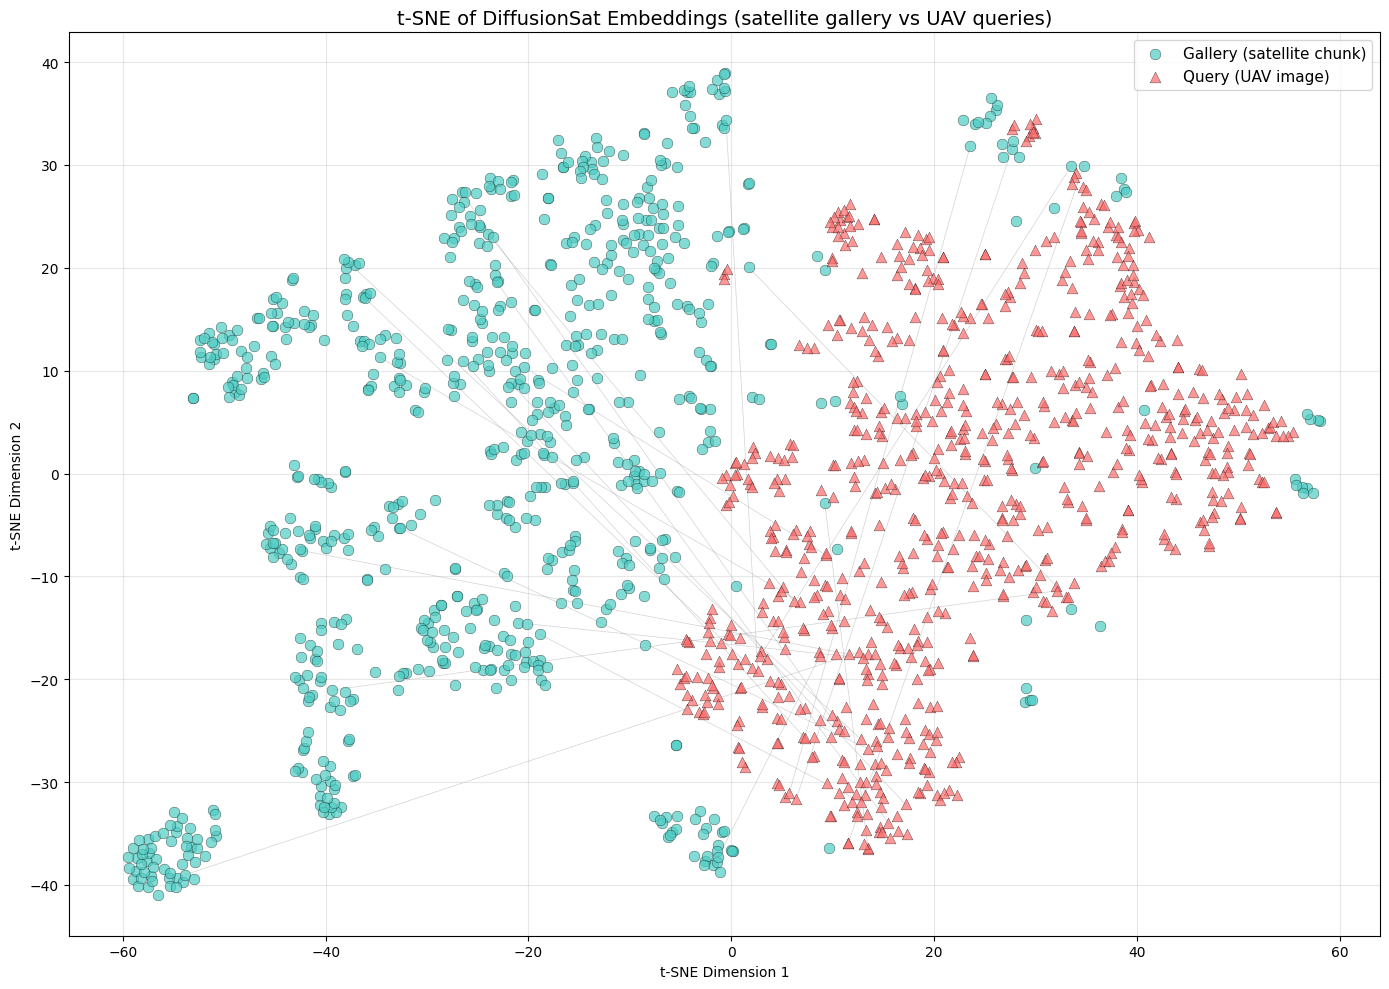

In [19]:
# fmt: off
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


def plot_tsne(gallery: torch.Tensor, query: torch.Tensor, ground_truth: list[set], n_display: int = 300) -> None:
  """t-SNE of gallery (satellite chunks) and query (UAV images) embeddings.
  Lines connect each UAV query to its ground-truth satellite chunk(s) if displayed."""
  rng = np.random.default_rng(42)
  g_idx = rng.choice(len(gallery), min(n_display, len(gallery)), replace=False)
  q_idx = rng.choice(len(query), min(n_display, len(query)), replace=False)

  g_sub = gallery[g_idx].cpu().numpy()
  q_sub = query[q_idx].cpu().numpy()
  all_embs = np.concatenate([g_sub, q_sub])

  coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(all_embs)
  ng = len(g_sub)
  g_coords, q_coords = coords[:ng], coords[ng:]

  # Map original gallery index → position in g_coords for fast GT lookup.
  g_idx_to_pos = {int(orig): pos for pos, orig in enumerate(g_idx)}

  fig, ax = plt.subplots(figsize=(14, 10))

  # Draw GT lines first (behind points).
  for q_pos, q_orig in enumerate(q_idx):
    for gt_chunk_idx in ground_truth[int(q_orig)]:
      if gt_chunk_idx in g_idx_to_pos:
        g_pos = g_idx_to_pos[gt_chunk_idx]
        ax.plot(
          [q_coords[q_pos, 0], g_coords[g_pos, 0]],
          [q_coords[q_pos, 1], g_coords[g_pos, 1]],
          color="gray", linewidth=0.5, alpha=0.35, zorder=1,
        )

  ax.scatter(*g_coords.T, c="#4ECDC4", s=60, alpha=0.7, edgecolors="black", linewidth=0.3, zorder=2, label="Gallery (satellite chunk)")
  ax.scatter(*q_coords.T, c="#FF6B6B", s=60, alpha=0.7, edgecolors="black", linewidth=0.3, zorder=2, marker="^", label="Query (UAV image)")

  ax.legend(fontsize=11)
  ax.set_title("t-SNE of DiffusionSat Embeddings (satellite gallery vs UAV queries)", fontsize=14)
  ax.set_xlabel("t-SNE Dimension 1")
  ax.set_ylabel("t-SNE Dimension 2")
  ax.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()


plot_tsne(gallery_embs, uav_embs, ground_truth, len(uav_embs))

In [25]:
def visualize_retrievals(
  preds: np.ndarray,
  ground_truth: list,
  uav_ds,
  gallery_ds,
  uav_embs: torch.Tensor,
  gallery_embs: torch.Tensor,
  n_queries: int = 6,
  top_k: int = 5,
  mode: str = "hard",
) -> None:
  """Show UAV queries alongside top-k satellite retrievals. Green border = correct."""
  gt_sims = []
  for i, gt_set in enumerate(ground_truth):
    q_emb = uav_embs[i].numpy()
    g_embs = gallery_embs[list(gt_set)].numpy()
    gt_sims.append(float(np.max(q_emb @ g_embs.T)))
  gt_sims = np.array(gt_sims)

  if mode == "hard":
    query_indices = np.argsort(gt_sims)[:n_queries]
  else:
    query_indices = np.random.default_rng(42).choice(
      len(uav_ds), n_queries, replace=False
    )

  fig, axes = plt.subplots(
    n_queries, top_k + 1, figsize=(2.5 * (top_k + 1), 2.5 * n_queries)
  )

  def _to_display(t):
    return (t * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

  for row, q_idx in enumerate(query_indices):
    uav_img, uav_lat, uav_lon = uav_ds[q_idx]
    gt_set = ground_truth[q_idx]

    ax = axes[row, 0]
    ax.imshow(_to_display(uav_img))
    ax.set_title(
      f"UAV {q_idx}\n({uav_lat:.5f}, {uav_lon:.5f})\nsim={gt_sims[q_idx]:.3f}",
      fontsize=7,
    )
    ax.axis("off")

    for col in range(top_k):
      chunk_idx = int(preds[q_idx, col])
      sat_img_t, _, _ = gallery_ds[chunk_idx]
      is_correct = chunk_idx in gt_set

      ax = axes[row, col + 1]
      ax.imshow(_to_display(sat_img_t))
      color = "#2ECC71" if is_correct else "#E74C3C"
      for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
      ax.set_title(f"Rank {col + 1}", fontsize=7)
      ax.axis("off")

  plt.suptitle(
    f"UAV→Satellite Retrieval — FuserEmbedder (mode={mode})",
    fontsize=11,
    y=1.01,
  )
  plt.tight_layout()
  plt.show()


visualize_retrievals(
  preds,
  ground_truth,
  uav_dataset,
  gallery_dataset,
  uav_embs,
  gallery_embs,
  n_queries=6,
  top_k=5,
  mode="hard",
)
visualize_retrievals(
  preds,
  ground_truth,
  uav_dataset,
  gallery_dataset,
  uav_embs,
  gallery_embs,
  n_queries=6,
  top_k=5,
  mode="random",
)


IndexError: index 40668 is out of bounds for dimension 0 with size 30